# Mapillary Class Review
Generates contact sheets for each class so we can visually decide which are US signs and which to keep.

In [1]:
import os
import json
import math
import csv
from collections import defaultdict
from pathlib import Path
from IPython.display import display, Image as IPImage
import ipywidgets as widgets

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

## Configuration
Set `DATASET_ROOT` to wherever `mtsd_v2_fully_annotated` lives on your machine.

In [2]:
DATASET_ROOT = "dataset/mtsd_v2_fully_annotated"
OUTPUT_DIR   = "contact_sheets"
CSV_PATH     = "mapillary_class_review_eu.csv"

N_SAMPLES    = 12     # crops to show per class
COLS         = 4      # grid columns
CROP_PAD     = 0.35   # fractional padding around each bbox
DPI          = 80
USE_SPLITS   = ["train", "val", "test"]

ANNOTATIONS_DIR = Path(DATASET_ROOT) / "annotations"
IMAGES_DIR      = Path(DATASET_ROOT) / "images"
SPLITS_DIR      = Path(DATASET_ROOT) / "splits"

Path(OUTPUT_DIR).mkdir(exist_ok=True)

## Step 1 — Load image keys from splits

In [3]:
def load_keys(splits_dir, use_splits):
    keys = []
    for split in use_splits:
        path = splits_dir / f"{split}.txt"
        if not path.exists():
            print(f"[warn] not found: {path}")
            continue
        with open(path) as f:
            keys += [l.strip() for l in f if l.strip()]
    return keys

keys = load_keys(SPLITS_DIR, USE_SPLITS)
print(f"{len(keys):,} images loaded")

52,453 images loaded


## Step 2 — Scan annotations and group crops by label

In [4]:
def collect_crops(keys):
    label_to_crops = defaultdict(list)
    missing = 0

    for image_key in keys:
        ann_path = ANNOTATIONS_DIR / f"{image_key}.json"
        if not ann_path.exists():
            missing += 1
            continue

        with open(ann_path) as f:
            ann = json.load(f)

        for obj in ann.get("objects", []):
            label = obj.get("label", "")
            bbox  = obj.get("bbox", {})
            if not label or not bbox:
                continue

            # Skip ambiguous / out-of-frame / dummy annotations
            props = obj.get("properties", {})
            if props.get("ambiguous") or props.get("out-of-frame") or props.get("dummy"):
                continue

            label_to_crops[label].append({"image_key": image_key, "bbox": bbox})

    if missing:
        print(f"[warn] {missing} annotation files not found")
    print(f"{len(label_to_crops)} unique labels found")
    return label_to_crops

label_to_crops = collect_crops(keys)

[warn] 10544 annotation files not found
401 unique labels found


## Step 3 — Generate and save all contact sheets
Run this once. Skip if you've already generated them.

In [8]:
def crop_sign(img, bbox, pad):
    xmin, ymin, xmax, ymax = bbox["xmin"], bbox["ymin"], bbox["xmax"], bbox["ymax"]
    w, h = xmax - xmin, ymax - ymin
    x1 = max(0,          xmin - w * pad)
    y1 = max(0,          ymin - h * pad)
    x2 = min(img.width,  xmax + w * pad)
    y2 = min(img.height, ymax + h * pad)
    return img.crop((x1, y1, x2, y2))


def save_contact_sheet(label, crops):
    """Renders a contact sheet and saves it to OUTPUT_DIR. Returns the output path."""
    samples = crops[:N_SAMPLES]
    rows    = math.ceil(len(samples) / COLS)

    fig, axes = plt.subplots(rows, COLS,
                             figsize=(COLS * 3, rows * 3),
                             squeeze=False)
    fig.suptitle(label, fontsize=9, fontweight="bold")

    shown = 0
    for sample in samples:
        img_path = IMAGES_DIR / f"{sample['image_key']}.jpg"
        if not img_path.exists():
            continue
        try:
            img     = Image.open(img_path).convert("RGB")
            cropped = crop_sign(img, sample["bbox"], CROP_PAD)
            r, c    = divmod(shown, COLS)
            axes[r][c].imshow(cropped)
            axes[r][c].axis("off")
            shown  += 1
        except Exception as e:
            print(f"  [warn] {img_path.name}: {e}")

    for idx in range(shown, rows * COLS):
        r, c = divmod(idx, COLS)
        axes[r][c].axis("off")

    safe_name = label.replace("/", "_").replace("\\", "_")
    out_path  = Path(OUTPUT_DIR) / f"{safe_name}.png"
    plt.savefig(out_path, bbox_inches="tight", dpi=DPI)
    plt.close(fig)
    return out_path


labels = sorted(label_to_crops.keys())
total  = len(labels)

for i, label in enumerate(labels, 1):
    out_path = Path(OUTPUT_DIR) / f"{label.replace('/', '_')}.png"
    if out_path.exists():
        continue  # already generated, skip
    save_contact_sheet(label, label_to_crops[label])
    if i % 25 == 0 or i == total:
        print(f"  {i}/{total} done")

print("All contact sheets saved.")

All contact sheets saved.


## Step 4 — Interactive review widget
Use the buttons to mark each class. Your decisions are saved automatically to `mapillary_class_review.csv` as you go, so you can close and resume any time.

In [9]:
# ── Load existing decisions so you can resume a previous session ──────────────
decisions = {}  # label -> {is_eu, keep, notes}

if Path(CSV_PATH).exists():
    with open(CSV_PATH, newline="") as f:
        for row in csv.DictReader(f):
            decisions[row["label"]] = {
                "is_eu": row["is_eu"],
                "keep":  row["keep"],
                "notes": row["notes"],
            }

def save_csv():
    with open(CSV_PATH, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["label","category","sample_count","is_eu","keep","notes"])
        writer.writeheader()
        for label in sorted(label_to_crops):
            d = decisions.get(label, {"is_eu": "", "keep": "", "notes": ""})
            writer.writerow({
                "label":        label,
                "category":     label.split("--")[0],
                "sample_count": len(label_to_crops[label]),
                "is_eu":        d["is_eu"],
                "keep":         d["keep"],
                "notes":        d["notes"],
            })

# Find first unreviewed label to start from
unreviewed = [l for l in labels if decisions.get(l, {}).get("keep", "") == ""]
start_idx  = labels.index(unreviewed[0]) if unreviewed else 0
state      = {"idx": start_idx}

print(f"{len(labels) - len(unreviewed)}/{len(labels)} already reviewed. Starting at index {start_idx}.")

0/401 already reviewed. Starting at index 0.


In [ ]:
# ── Build the widget UI ───────────────────────────────────────────────────────

img_out      = widgets.Output()
status_label = widgets.Label()
notes_box    = widgets.Text(placeholder="optional notes", layout=widgets.Layout(width="400px"))

def make_btn(label, color):
    return widgets.Button(description=label,
                          style={"button_color": color},
                          layout=widgets.Layout(width="120px"))

btn_yes    = make_btn("✅ Keep",    "#c8f7c5")
btn_buffer = make_btn("🟡 Buffer",  "#fef9c3")
btn_no     = make_btn("❌ Skip",    "#fdd")
btn_prev   = make_btn("⬅ Prev",    "#e0e0e0")
btn_jump   = make_btn("↩ Jump to…","#e0e0e0")
jump_input = widgets.IntText(value=0, layout=widgets.Layout(width="80px"))


def show_current():
    idx   = state["idx"]
    label = labels[idx]
    d     = decisions.get(label, {})

    reviewed = len([l for l in labels if decisions.get(l, {}).get("keep", "") != ""])
    status_label.value = (f"[{idx+1}/{len(labels)}]  "
                          f"{reviewed} reviewed, {len(unreviewed)} remaining  |  "
                          f"{label}  ({len(label_to_crops[label])} samples)")
    notes_box.value = d.get("notes", "")

    sheet_path = Path(OUTPUT_DIR) / f"{label.replace('/', '_')}.png"
    with img_out:
        img_out.clear_output(wait=True)
        if sheet_path.exists():
            display(IPImage(filename=str(sheet_path), width=800))
        else:
            print(f"Contact sheet not found: {sheet_path}")


def record(keep_value):
    label = labels[state["idx"]]
    decisions[label] = {
        "is_eu": "yes" if keep_value in ("yes", "buffer") else "no",
        "keep":  keep_value,
        "notes": notes_box.value.strip(),
    }
    save_csv()
    if state["idx"] < len(labels) - 1:
        state["idx"] += 1
    show_current()

btn_yes.on_click(   lambda _: record("yes"))
btn_buffer.on_click(lambda _: record("buffer"))
btn_no.on_click(    lambda _: record("no"))

def go_prev(_):
    if state["idx"] > 0:
        state["idx"] -= 1
    show_current()

def go_jump(_):
    idx = max(0, min(len(labels) - 1, jump_input.value - 1))
    state["idx"] = idx
    show_current()

btn_prev.on_click(go_prev)
btn_jump.on_click(go_jump)

ui = widgets.VBox([
    status_label,
    img_out,
    widgets.HBox([btn_yes, btn_buffer, btn_no, btn_prev]),
    widgets.HBox([widgets.Label("Notes:"), notes_box]),
    widgets.HBox([btn_jump, jump_input, widgets.Label("(1-indexed)")]),
])

show_current()
display(ui)

## Step 5 — Summary of decisions

In [11]:
from collections import Counter

counts = Counter(d["keep"] for d in decisions.values())
total_reviewed = sum(counts.values())

print(f"Total classes:    {len(labels)}")
print(f"Reviewed:         {total_reviewed}")
print(f"  Keep:           {counts.get('yes', 0)}")
print(f"  Buffer classes: {counts.get('buffer', 0)}")
print(f"  Skip:           {counts.get('no', 0)}")
print(f"  Unreviewed:     {len(labels) - total_reviewed}")
print(f"\nCSV saved to: {CSV_PATH}")

Total classes:    401
Reviewed:         401
  Keep:           51
  Buffer classes: 0
  Skip:           350
  Unreviewed:     0

CSV saved to: mapillary_class_review_eu.csv


Keep: 51  |  Buffer: 0
Counting annotations (this may take a minute)...
Done.


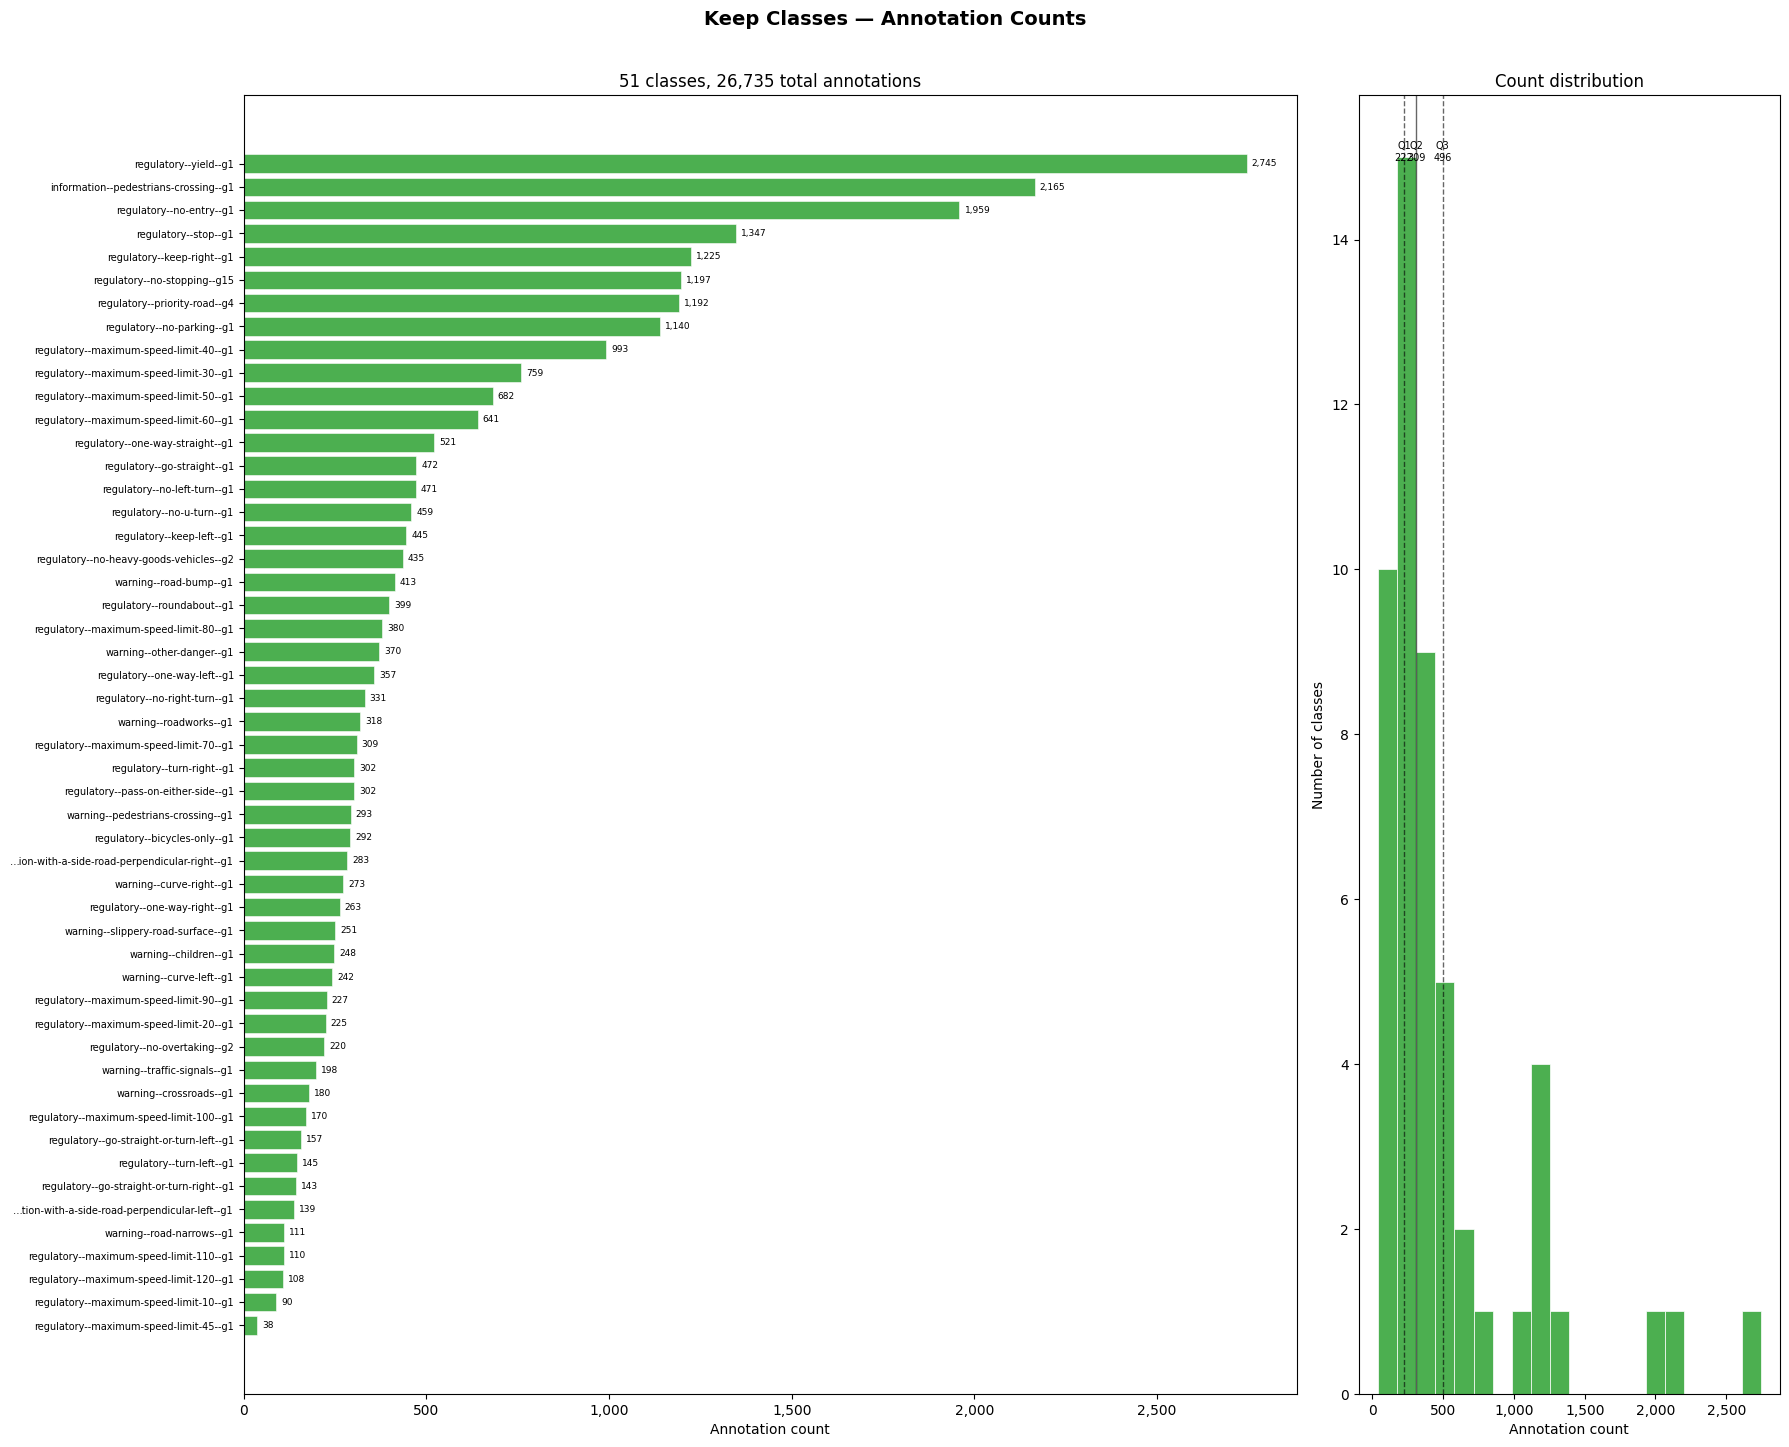


─────────────────────────────────────────────
  Total annotations :     26,735
  Mean per class    :      524.2
  Median per class  :      309.0
  Min               :         38  (regulatory--maximum-speed-limit-45--g1)
  Max               :      2,745  (regulatory--yield--g1)
  Classes < 100     :          2
  Classes < 500     :         38
─────────────────────────────────────────────



IndexError: index -1 is out of bounds for axis 0 with size 0

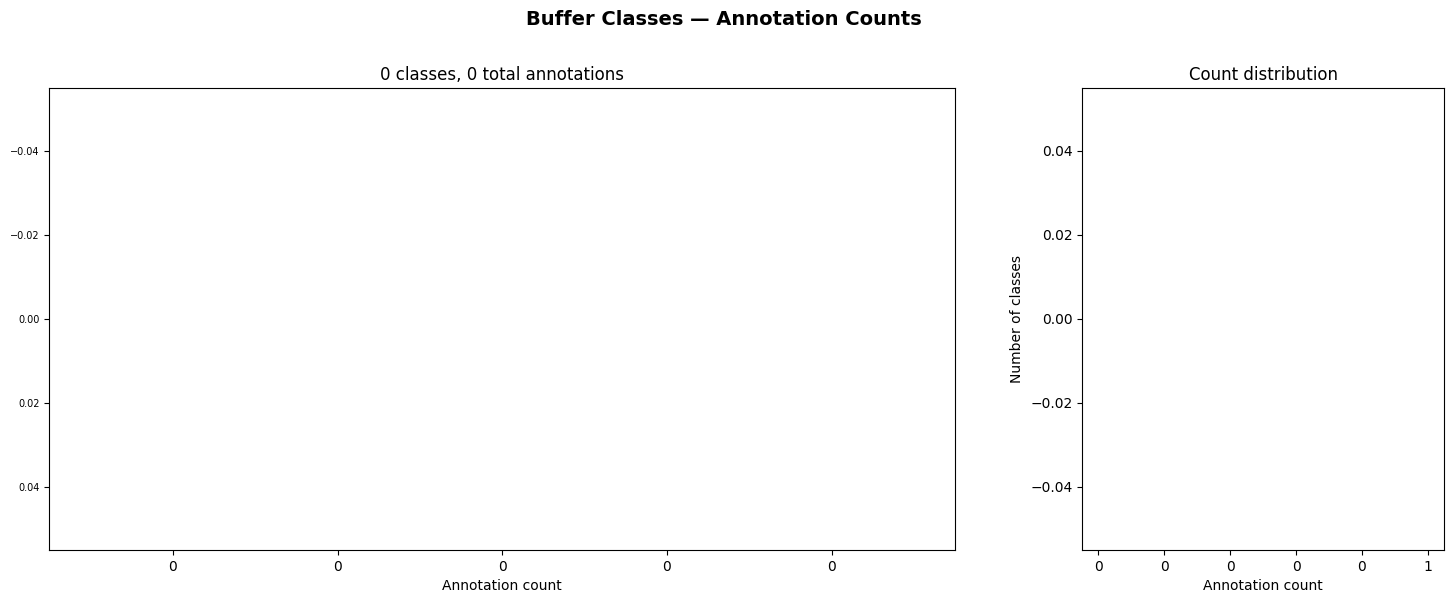

In [12]:
import csv
import json
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Load decisions from CSV ───────────────────────────────────────────────────

def load_decisions(csv_path):
    keep, buffer = [], []
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f):
            if row["keep"] == "yes":
                keep.append(row["label"])
            elif row["keep"] == "buffer":
                buffer.append(row["label"])
    return keep, buffer

keep_labels, buffer_labels = load_decisions(CSV_PATH)
print(f"Keep: {len(keep_labels)}  |  Buffer: {len(buffer_labels)}")


# ── Count annotations per label across all splits ────────────────────────────

def count_annotations(keys, target_labels):
    """Returns {label: count} for labels in target_labels."""
    target_set = set(target_labels)
    counts = defaultdict(int)

    for image_key in keys:
        ann_path = ANNOTATIONS_DIR / f"{image_key}.json"
        if not ann_path.exists():
            continue
        with open(ann_path) as f:
            ann = json.load(f)
        for obj in ann.get("objects", []):
            label = obj.get("label", "")
            if label not in target_set:
                continue
            props = obj.get("properties", {})
            if props.get("ambiguous") or props.get("out-of-frame") or props.get("dummy"):
                continue
            counts[label] += 1

    # Ensure every target label appears, even if count is 0
    for label in target_labels:
        if label not in counts:
            counts[label] = 0

    return counts

print("Counting annotations (this may take a minute)...")
keep_counts   = count_annotations(keys, keep_labels)
buffer_counts = count_annotations(keys, buffer_labels)
print("Done.")


# ── Plot ──────────────────────────────────────────────────────────────────────

def plot_class_distribution(counts_dict, title, color):
    """
    Two-panel figure:
      Left  — horizontal bar chart of every class sorted by count
      Right — histogram showing the distribution of counts
    """
    labels  = sorted(counts_dict, key=counts_dict.get, reverse=True)
    values  = [counts_dict[l] for l in labels]
    n       = len(labels)

    # Shorten label names for readability on the bar chart
    def short(label, maxlen=45):
        return label if len(label) <= maxlen else "…" + label[-(maxlen-1):]

    short_labels = [short(l) for l in labels]

    fig, (ax_bar, ax_hist) = plt.subplots(
        1, 2,
        figsize=(18, max(6, n * 0.28)),
        gridspec_kw={"width_ratios": [3, 1.2]}
    )
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    # ── Left: horizontal bar chart ────────────────────────────────────────────
    bars = ax_bar.barh(short_labels, values, color=color, edgecolor="white", linewidth=0.4)
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("Annotation count")
    ax_bar.set_title(f"{n} classes, {sum(values):,} total annotations")
    ax_bar.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_bar.tick_params(axis="y", labelsize=7)

    # Annotate each bar with its count
    for bar, val in zip(bars, values):
        ax_bar.text(
            bar.get_width() + max(values) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}",
            va="center", ha="left", fontsize=6.5
        )

    # ── Right: histogram ──────────────────────────────────────────────────────
    ax_hist.hist(values, bins=20, color=color, edgecolor="white", linewidth=0.5)
    ax_hist.set_xlabel("Annotation count")
    ax_hist.set_ylabel("Number of classes")
    ax_hist.set_title("Count distribution")
    ax_hist.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # Annotate quartiles on the histogram
    for q, ls in zip([25, 50, 75], ["--", "-", "--"]):
        qval = np.percentile(values, q)
        ax_hist.axvline(qval, color="black", linestyle=ls, linewidth=1, alpha=0.6)
        ax_hist.text(qval, ax_hist.get_ylim()[1] * 0.95,
                     f"Q{q//25 if q!=50 else 2}\n{qval:,.0f}",
                     ha="center", fontsize=7, color="black")

    plt.tight_layout()
    plt.show()

    # ── Print quick stats ─────────────────────────────────────────────────────
    arr = np.array(values)
    print(f"\n{'─'*45}")
    print(f"  Total annotations : {arr.sum():>10,}")
    print(f"  Mean per class    : {arr.mean():>10,.1f}")
    print(f"  Median per class  : {np.median(arr):>10,.1f}")
    print(f"  Min               : {arr.min():>10,}  ({labels[np.argmin(arr)]})")
    print(f"  Max               : {arr.max():>10,}  ({labels[np.argmax(arr)]})")
    print(f"  Classes < 100     : {(arr < 100).sum():>10}")
    print(f"  Classes < 500     : {(arr < 500).sum():>10}")
    print(f"{'─'*45}\n")


plot_class_distribution(keep_counts,   "Keep Classes — Annotation Counts",   "#4CAF50")
plot_class_distribution(buffer_counts, "Buffer Classes — Annotation Counts", "#FFC107")
